In [1]:
# load libaries
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import matplotlib.patches as mpatches

In [2]:
netMHC1 = pd.read_csv('tool_outputs/netMHC1_defaultSettings.csv')
netMHC_II = pd.read_csv('tool_outputs/netMHC_II_defaultSettings.csv')
biophi = pd.read_excel('tool_outputs/biophi_defaultSettings.xlsx')
waltz = pd.read_csv('tool_outputs/waltz.txt', sep="\t", header=None, names=["antibody", "waltz_score", "..."])

In [3]:
# rename the antibodies in the netMHC1 and netMHC_II dataframes
netMHC1['seq #'] = netMHC1['seq #'].replace(1, 'Caplacizumab')
netMHC1['seq #'] = netMHC1['seq #'].replace(2, 'Capla_3')

netMHC_II['seq #'] = netMHC_II['seq #'].replace(1, 'Caplacizumab')
netMHC_II['seq #'] = netMHC_II['seq #'].replace(2, 'Capla_3')

In [4]:
# select the two columns anitbody and OASis Identity, and rename the "Antibody" column to "antibody" to make the merging easier.
biophi = biophi[['Antibody', 'OASis Identity']].rename(columns={'Antibody': 'antibody'})

In [5]:
# netMHC1 scores

# Immunogenentic is defened as scored <= 1%
# Here I calculate the percantage of peptide-HLA allele combinations (rows) that have a percentile score below 1. 
netMHC1_percentile = (
    netMHC1.assign(immunogenic=netMHC1['netmhcpan_el percentile'] <= 1) # flags rows where percentile is below 1
          .groupby('seq #')['immunogenic'] # calculates mean of immunogenic for each antibody, gives the fraction
          .mean()
          .mul(100) # multiplies by 100 to get percentage
          .reset_index(name='netMHC1_percentile')
    )

# netMHC1_EL_pep9 Immunogenicity score 

# Immunogenentic is defened as scored larger than 0
# Here I calculate the percantage of peptide-HLA allele combinations (rows) that have a immunogenicity score above 0. 
class1pMHC_immunogen = (
    netMHC1.assign(immunogenic=netMHC1['immunogenicity score'] > 0) # flags rows where percentile is above 0
          .groupby('seq #')['immunogenic'] # calculates mean of immunogenic for each antibody, gives the fraction
          .mean()
          .mul(100) # multiplies by 100 to get percentage
          .reset_index(name='class1pMHC_immunogen')
    )

# netMHC1_EL_pep9 Preprocessing score

# Immunogenentic is not defined
# Here I simply calculate the mean score for each antibody. 
basicPreProcessMCH1 = netMHC1.groupby('seq #')['processing total score'].mean().reset_index().rename(columns={'processing total score': 'basicPreProcessMCH1'})


# netMHC_II

# Percentile score

# Immunogenentic is defened as scored <= 10%
# Here I calculate the percantage of peptide-HLA allele combinations (rows) that have a percentile score below 10. 
netMHC_II_percentile = (
    netMHC_II.assign(immunogenic=netMHC_II['netmhciipan_el percentile'] <= 10) # flags rows where percentile is below 10
          .groupby('seq #')['immunogenic'] # calculates mean of immunogenic for each antibody, gives the fraction
          .mean()
          .mul(100) # multiplies by 100 to get percentage
          .reset_index(name='netMHC_II_percentile')
    )

# Immunogenicity score

# Immunogenentic is not defined
# Here I simply calculate the mean score for each antibody. 
CD4Episcore = netMHC_II.groupby('seq #')['immunogenicity score'].mean().reset_index().rename(columns={'immunogenicity score':'CD4Episcore'})

# Pre-proocessing score
# MHC class 2 has 2 preprocessing scores of interest: mhcii-np cleavage probability score and mhcii-np cleavage probability percentile rank

# mhcii-np cleavage probability

# remove the rows with the cleavage probability score of '-' before calculating the mean
netMHC_II = netMHC_II[netMHC_II['mhcii-np cleavage probability score'] != '-']
# make the column with the cleavage probability score into a numeric column
netMHC_II['mhcii-np cleavage probability score'] = pd.to_numeric(netMHC_II['mhcii-np cleavage probability score'])
# Compute score
# Immunogenentic is not defined
# Here I simply calculate the mean score for each antibody. 
MHCII_NP_cleavProb = netMHC_II.groupby('seq #')['mhcii-np cleavage probability score'].mean().reset_index().rename(columns={'processing total score': 'MHCII_NP_cleavProb'})

# mhcii-np cleavage probability percentile rank

# remove the rows with the cleavage probability percentile rank of '-' before calculating the mean
netMHC_II = netMHC_II[netMHC_II['mhcii-np cleavage probability percentile rank'] != '-']
# make the column with the cleavage probability percentile rank into a numeric column
netMHC_II['mhcii-np cleavage probability percentile rank'] = pd.to_numeric(netMHC_II['mhcii-np cleavage probability percentile rank'])
# compute score
# Immunogenentic is not defined
# Here I simply calculate the mean score for each antibody. 
MHCII_NP_cleavProbPercentile = netMHC_II.groupby('seq #')['mhcii-np cleavage probability percentile rank'].mean().reset_index().rename(columns={'mhcii-np cleavage probability percentile rank': 'MHCII_NP_cleavProbPercentile'})

# rename the column '...' to nr_aggs
waltz = waltz.rename(columns={'...': 'nr_aggs'})

# compute the total number of amio acids that are considerd immunogenetic
def sum_ranges(s):
    if pd.isna(s):
        return 0
    total = 0
    for part in s.split(';'):
        start, end = part.strip().split('-')
        total += int(end) - int(start) + 1 # beacuse the values are inclusive
    return total

waltz['nr_aggs'] = waltz['waltz_score'].apply(sum_ranges)

In [6]:
# create df with all the dfs that shall me merged into one
dfs_to_merge = [
    class1pMHC_immunogen,
    basicPreProcessMCH1,
    netMHC_II_percentile,
    CD4Episcore,
    MHCII_NP_cleavProb,
    MHCII_NP_cleavProbPercentile,
]

# Rename the sequence name column to antibody to make the merging easier. 
dfs_to_merge = [df.rename(columns={'seq #': 'antibody'}) for df in dfs_to_merge]

# Create the df with all scores, start with the ADA scores
netMHC1_percentile = netMHC1_percentile.rename(columns={'seq #': 'antibody'})
all_predictors = netMHC1_percentile

# Merge all dfs on antibody name
for df in dfs_to_merge:
    all_predictors = all_predictors.merge(df, on='antibody', how='left')

# remove all whitespaces in antobdy column
all_predictors['antibody'] = all_predictors['antibody'].str.strip()

# Then merge the three last dfs
all_predictors= all_predictors.merge(waltz[['antibody','nr_aggs']], on='antibody', how='left').rename(columns={'nr_aggs': 'waltz_nr_aggs'})
all_predictors = all_predictors.merge(biophi, on='antibody', how='left')


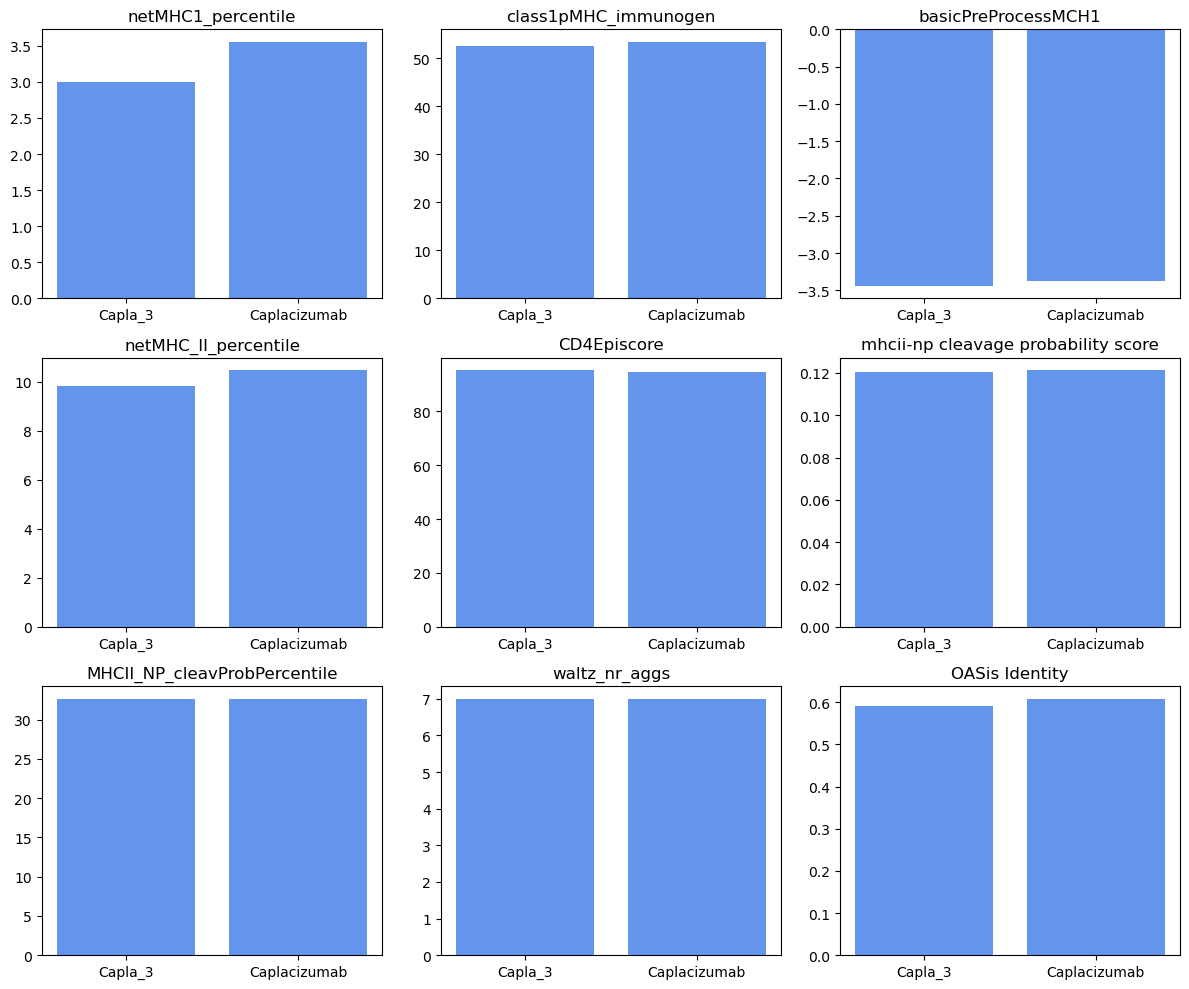

In [7]:

fig, axes = plt.subplots(3, 3, figsize=(12, 10))
axes = axes.flatten()
x = np.arange(len(all_predictors))

for i, col in enumerate(all_predictors.columns[1:]): # skip the first column with the sequence names
    ax = axes[i]
    
    
    values = all_predictors[col].values # 2 values (rows)

    ax.bar(x, values, color="cornflowerblue")
    ax.set_title(col)
    ax.set_xticks(x)
    ax.set_xticklabels(all_predictors['antibody'])

plt.tight_layout()
plt.show()